Top performers (sig & LFC > 0.5): 216
Bottom performers (sig & LFC < -0.5): 63

Total features to check: 75
Valid features for plotting: 56
Skipped features: 19


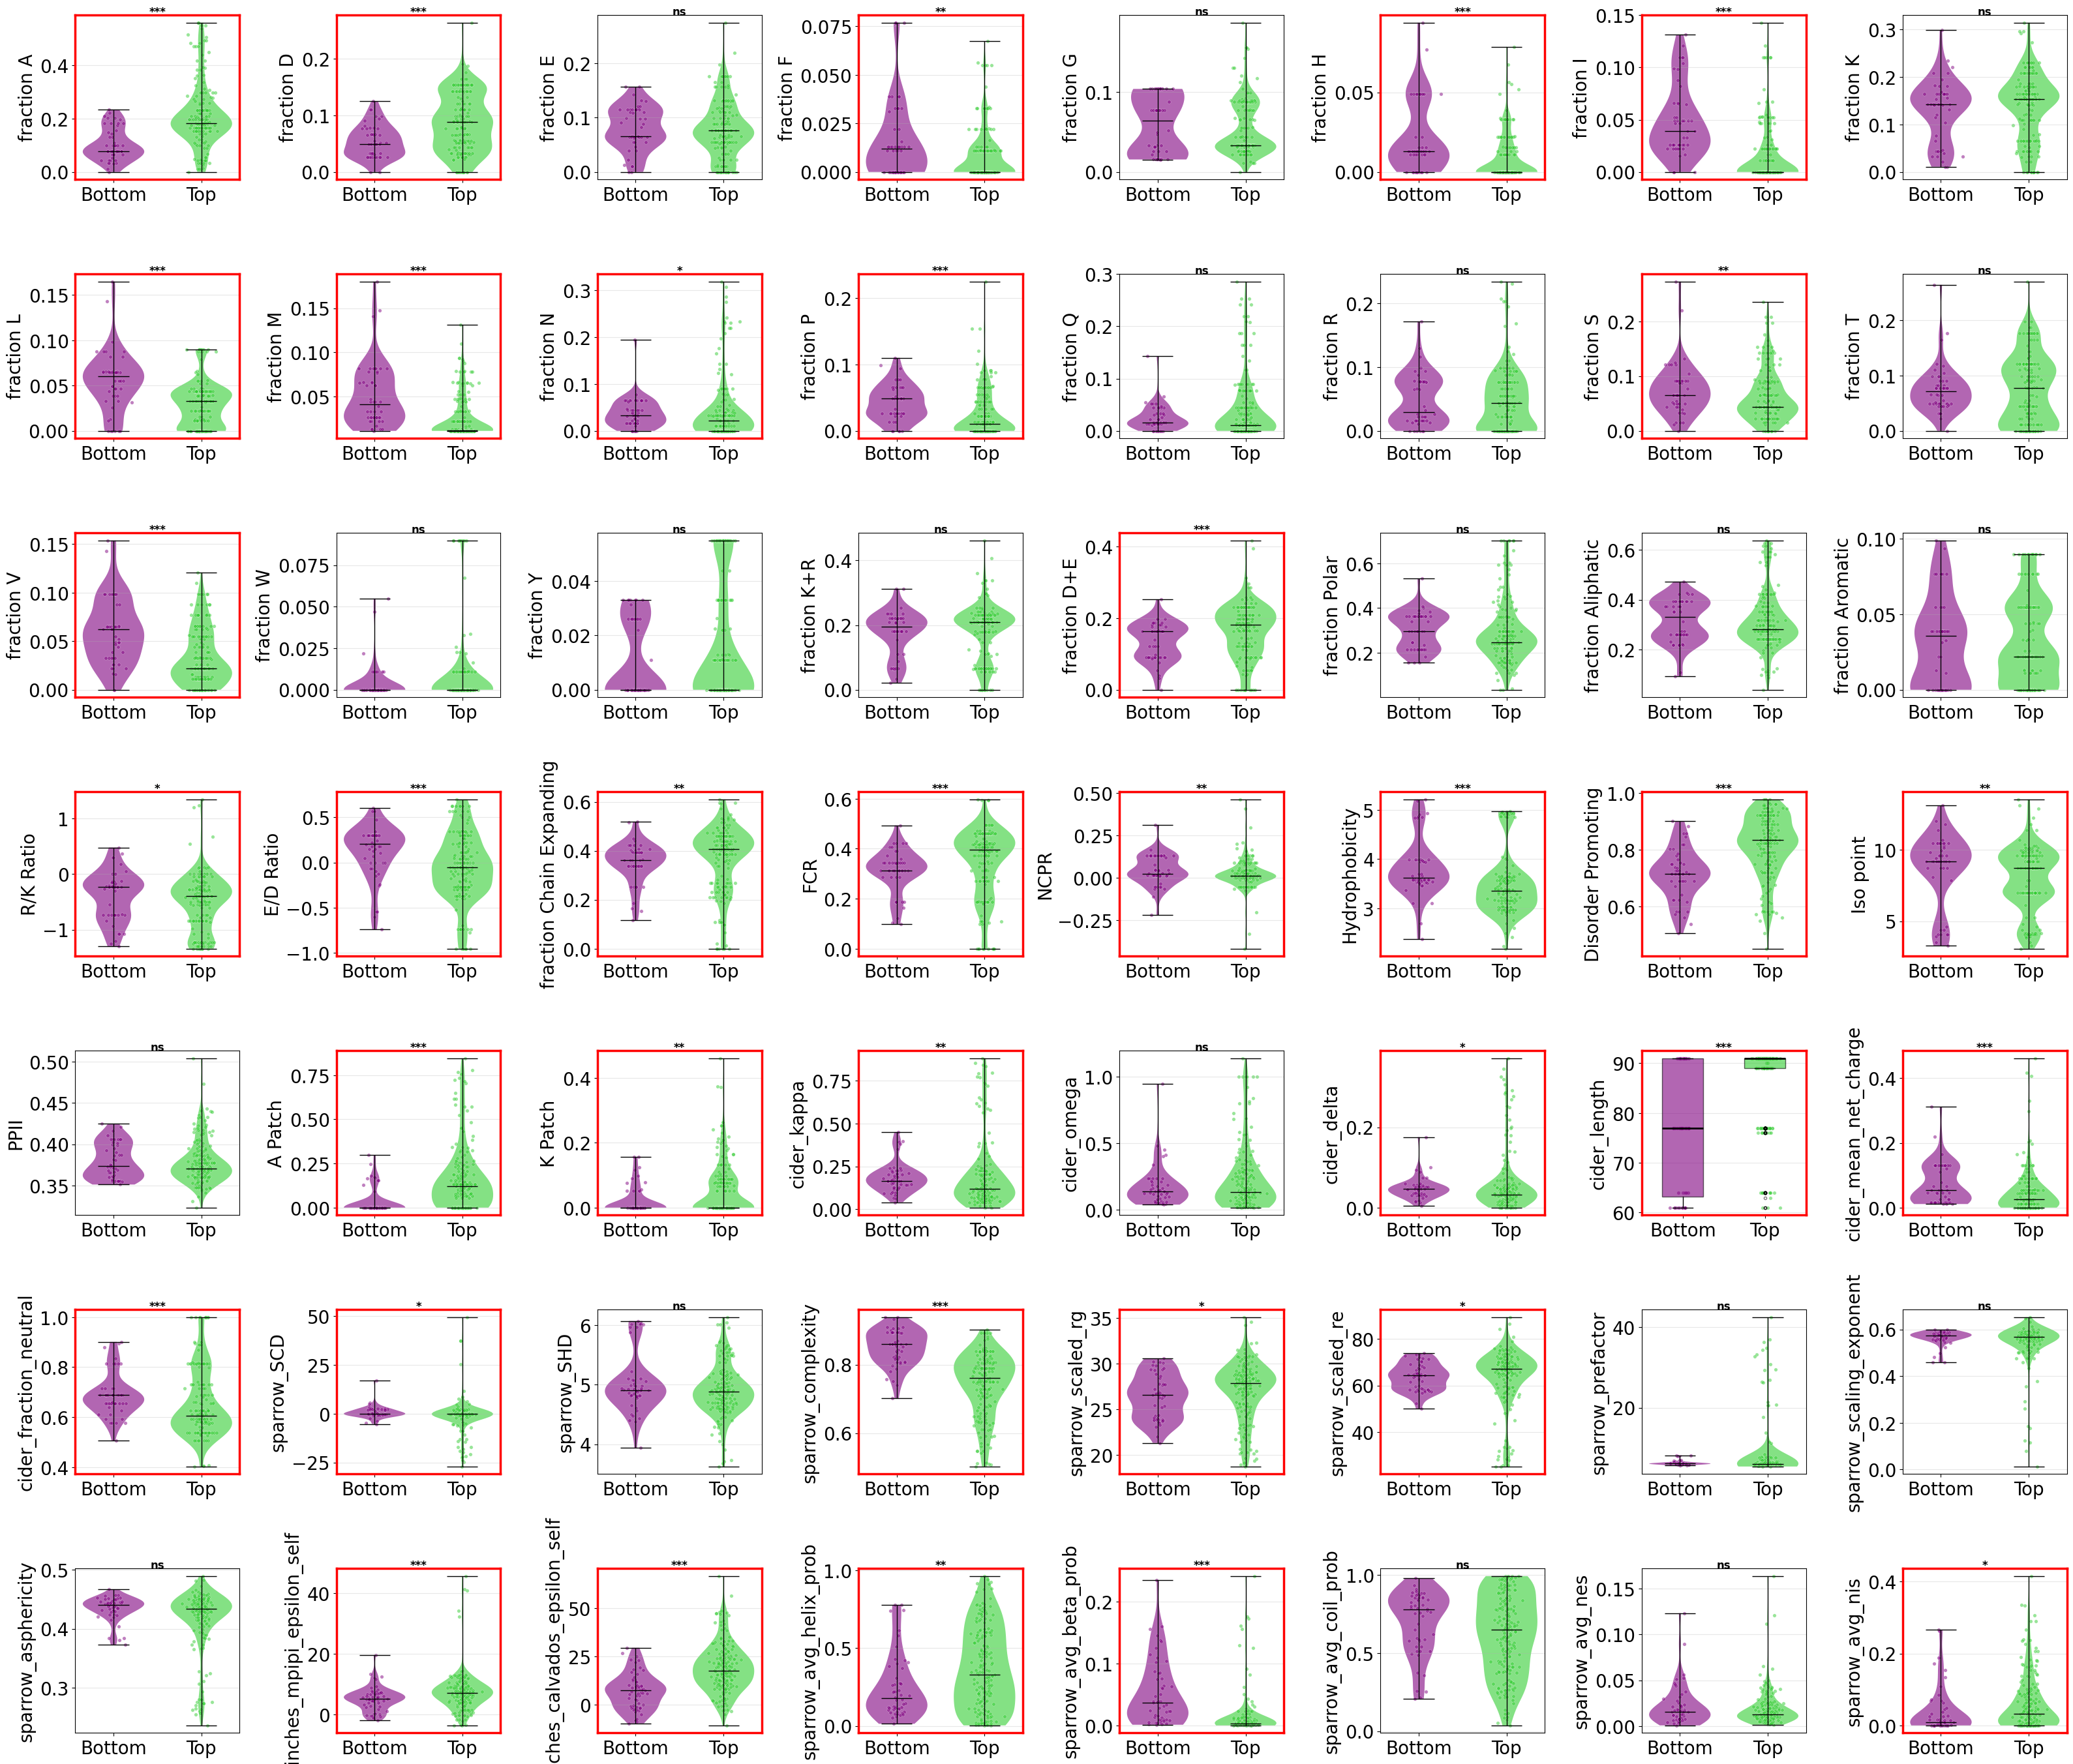


Significant features (padj < 0.05):
                         feature         padj    direction
              nardini_Frac I_raw 2.460816e-15 Bottom > Top
              sparrow_complexity 1.502103e-14 Bottom > Top
           sparrow_avg_beta_prob 2.763886e-14 Bottom > Top
   finches_calvados_epsilon_self 3.372400e-11 Top > Bottom
              nardini_Frac M_raw 3.372400e-11 Bottom > Top
              nardini_Frac A_raw 1.301551e-10 Top > Bottom
  nardini_Disorder Promoting_raw 2.201135e-10 Top > Bottom
                    cider_length 1.210647e-08 Top > Bottom
             nardini_A Patch_raw 2.852895e-08 Top > Bottom
              nardini_Frac L_raw 7.375730e-08 Bottom > Top
              nardini_Frac H_raw 5.610477e-07 Bottom > Top
              nardini_Frac V_raw 5.933160e-07 Bottom > Top
              nardini_Frac P_raw 1.446886e-06 Bottom > Top
      nardini_Hydrophobicity_raw 2.580439e-06 Bottom > Top
              nardini_Frac D_raw 1.498250e-05 Top > Bottom
           cider_me

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

# Load data
df1 = pd.read_csv('/../../Data/Figure_5/sequencing_data_all.csv')

# Identify columns for each replicate
lfc_cols = sorted([c for c in df1.columns if c.startswith('log2FoldChange_rep')
                   and c[-1] in ['1', '2', '3']])
se_cols = sorted([c for c in df1.columns if c.startswith('lfcSE_rep')
                  and c[-1] in ['1', '2', '3']])

# Extract data and calculate weighted statistics
lfc_data = df1[lfc_cols].values
se_data = df1[se_cols].values
weights = 1 / (se_data ** 2)

weighted_lfc = np.nansum(weights * lfc_data, axis=1) / np.nansum(weights, axis=1)
pooled_se = 1 / np.sqrt(np.nansum(weights, axis=1))
z_scores = weighted_lfc / pooled_se
pvalues = 2 * stats.norm.sf(np.abs(z_scores))

df1['weighted_log2FC'] = weighted_lfc
df1['pooled_SE'] = pooled_se
df1['pvalue'] = pvalues

# Multiple testing correction
valid_mask = np.isfinite(df1['pvalue'])
_, padj_values, _, _ = multipletests(df1.loc[valid_mask, 'pvalue'], method='fdr_bh')
df1['padj'] = np.nan
df1.loc[valid_mask, 'padj'] = padj_values

# Replace invalid values with NaN
if 'cider_kappa' in df1.columns:
    df1.loc[df1['cider_kappa'] == -1, 'cider_kappa'] = np.nan
if 'cider_omega' in df1.columns:
    df1.loc[df1['cider_omega'] == -1, 'cider_omega'] = np.nan
if 'sparrow_scaling_exponent' in df1.columns:
    df1.loc[df1['sparrow_scaling_exponent'] <= 0, 'sparrow_scaling_exponent'] = np.nan
if 'sparrow_asphericity' in df1.columns:
    df1.loc[df1['sparrow_asphericity'] < 0, 'sparrow_asphericity'] = np.nan

# Define top and bottom performers
sig_mask = df1['padj'] < 0.05
top_performers = df1[sig_mask & (df1['weighted_log2FC'] > 0.5)]
bottom_performers = df1[sig_mask & (df1['weighted_log2FC'] < -0.5)]

print(f"Top performers (sig & LFC > 0.5): {len(top_performers)}")
print(f"Bottom performers (sig & LFC < -0.5): {len(bottom_performers)}")

# Define feature columns - ONLY _raw, exclude _zscore
EXCLUDE_FEATURES = {'nardini_Frac C_raw'}
nardini_cols = [col for col in df1.columns if col.startswith('nardini_') and col.endswith('_raw')
                and col not in EXCLUDE_FEATURES]

other_features = [
    'cider_kappa', 'cider_omega', 'cider_delta', 'cider_length',
    'cider_mean_net_charge', 'cider_fraction_neutral',
    'sparrow_SCD', 'sparrow_SHD', 'sparrow_complexity',
    'sparrow_scaled_rg', 'sparrow_scaled_re',
    'sparrow_prefactor', 'sparrow_scaling_exponent', 'sparrow_asphericity',
    'finches_mpipi_epsilon_self', 'finches_calvados_epsilon_self'
]

new_feature_cols = [
    'sparrow_avg_helix_prob', 'sparrow_avg_beta_prob', 'sparrow_avg_coil_prob',
    'sparrow_avg_mito_targeting', 'sparrow_avg_nes', 'sparrow_avg_nis'
]

all_features = nardini_cols + other_features + new_feature_cols
chem_cols = [col for col in all_features if col in df1.columns]

print(f"\nTotal features to check: {len(chem_cols)}")

# Pre-filter features
MIN_SAMPLES = 10
MIN_UNIQUE = 3

valid_features = []
skipped_features = []

for feature in chem_cols:
    top_data = top_performers[feature].dropna().values
    bottom_data = bottom_performers[feature].dropna().values

    if len(top_data) < MIN_SAMPLES:
        skipped_features.append((feature, f'Top group has only {len(top_data)} samples'))
        continue
    if len(bottom_data) < MIN_SAMPLES:
        skipped_features.append((feature, f'Bottom group has only {len(bottom_data)} samples'))
        continue

    top_unique = len(np.unique(top_data))
    bottom_unique = len(np.unique(bottom_data))

    if top_unique < MIN_UNIQUE or bottom_unique < MIN_UNIQUE:
        skipped_features.append((feature, 'Insufficient unique values'))
        continue

    top_zero_frac = np.sum(top_data == 0) / len(top_data)
    bottom_zero_frac = np.sum(bottom_data == 0) / len(bottom_data)

    if top_zero_frac > 0.9 or bottom_zero_frac > 0.9:
        skipped_features.append((feature, 'Excessive zeros'))
        continue

    valid_features.append(feature)

print(f"Valid features for plotting: {len(valid_features)}")
print(f"Skipped features: {len(skipped_features)}")

# Features to render as boxplots instead of violins (e.g. discrete values)
BOXPLOT_FEATURES = {'cider_length'}

# Calculate grid dimensions
n_features = len(valid_features)
n_cols = 8
n_rows = int(np.ceil(n_features / n_cols))

panel_size = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * panel_size, n_rows * panel_size))
axes = axes.flatten()

stat_results = []

for i, feature in enumerate(valid_features):
    ax = axes[i]

    top_data = top_performers[feature].dropna().values
    bottom_data = bottom_performers[feature].dropna().values

    try:
        if feature in BOXPLOT_FEATURES:
            bp = ax.boxplot(
                [bottom_data, top_data],
                positions=[0, 1],
                patch_artist=True,
                widths=0.5,
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                flierprops=dict(marker='o', markersize=3, alpha=0.5)
            )
            bp['boxes'][0].set_facecolor('purple');  bp['boxes'][0].set_alpha(0.6)
            bp['boxes'][1].set_facecolor('limegreen'); bp['boxes'][1].set_alpha(0.6)
        else:
            parts = ax.violinplot([bottom_data, top_data], positions=[0, 1],
                                  showmeans=False, showmedians=True, widths=0.7)
            parts['bodies'][0].set_facecolor('purple')
            parts['bodies'][0].set_alpha(0.6)
            parts['bodies'][1].set_facecolor('limegreen')
            parts['bodies'][1].set_alpha(0.6)
            for partname in ['cbars', 'cmins', 'cmaxes', 'cmedians']:
                parts[partname].set_edgecolor('black')
                parts[partname].set_linewidth(1)

        jitter_bottom = np.random.normal(0, 0.06, len(bottom_data))
        jitter_top = np.random.normal(1, 0.06, len(top_data))
        ax.scatter(jitter_bottom, bottom_data, alpha=0.5, s=15, c='purple',
                   edgecolors='white', linewidths=0.3)
        ax.scatter(jitter_top, top_data, alpha=0.5, s=15, c='limegreen',
                   edgecolors='white', linewidths=0.3)

        stat, pval = stats.mannwhitneyu(top_data, bottom_data, alternative='two-sided')
        stat_results.append({'feature': feature, 'pvalue': pval,
                             'top_median': np.median(top_data),
                             'bottom_median': np.median(bottom_data),
                             'top_n': len(top_data),
                             'bottom_n': len(bottom_data)})

        sig_text = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        y_max = max(np.max(top_data), np.max(bottom_data))
        y_min = min(np.min(top_data), np.min(bottom_data))
        y_range = y_max - y_min if (y_max - y_min) != 0 else 1
        ax.text(0.5, y_max + 0.05 * y_range, sig_text, ha='center', fontsize=12, fontweight='bold')

    except Exception as e:
        ax.boxplot([bottom_data, top_data], positions=[0, 1], patch_artist=True, widths=0.5)
        print(f"Warning: Plot failed for {feature}: {e}")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Bottom', 'Top'], fontsize=20)
    ylabel = feature.replace('nardini_', '').replace('_raw', '').replace('Frac ', 'fraction ')
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_box_aspect(1)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# --- Highlight significant panels with red border (requires padj) ---
stat_df_pre = pd.DataFrame(stat_results)
_, stat_df_pre['padj'], _, _ = multipletests(stat_df_pre['pvalue'], method='fdr_bh')
sig_features = set(stat_df_pre.loc[stat_df_pre['padj'] < 0.05, 'feature'])

for i, feature in enumerate(valid_features):
    if feature in sig_features:
        for spine in axes[i].spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2.5)

plt.tight_layout(pad=1.5)
plt.rcParams['svg.fonttype'] = 'none'
#plt.savefig('violin_top_vs_bottom_raw.svg', format='svg', bbox_inches='tight')
#plt.savefig('violin_top_vs_bottom_raw.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics summary
stat_df = pd.DataFrame(stat_results)
_, stat_df['padj'], _, _ = multipletests(stat_df['pvalue'], method='fdr_bh')
stat_df['significant'] = stat_df['padj'] < 0.05
stat_df['direction'] = np.where(stat_df['top_median'] > stat_df['bottom_median'],
                                 'Top > Bottom', 'Bottom > Top')
stat_df = stat_df.sort_values('pvalue')
#stat_df.to_csv('violin_statistics_raw.csv', index=False)

print("\n" + "="*80)
print("Significant features (padj < 0.05):")
print("="*80)
print(stat_df[stat_df['significant']][['feature', 'padj', 'direction']].to_string(index=False))